# ⚙️ Configuration

In [10]:
from tensorflow.keras.callbacks import Callback 
from keras import models, layers 
from matplotlib import pyplot as plt 
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report 
from tensorflow.keras.utils import to_categorical 
from sklearn.model_selection import train_test_split 
from tensorflow.keras import regularizers 
from tensorflow.keras.callbacks import ModelCheckpoint
!pip install --upgrade ipython -q
%load_ext autoreload
%autoreload 2
import ds_tool_kit as dk
from ds_tool_kit import *

^C
ERROR: Operation cancelled by user
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
SEED = 42
IMG_SIZE = (150, 150)
BATCH_SIZE = 32
os.environ['PYTHONHASHSEED'] = str(SEED) 
os.environ['TF_DETERMINISTIC_OPS'] = '1' 
tf.config.threading.set_intra_op_parallelism_threads(1) 
tf.config.threading.set_inter_op_parallelism_threads(1) 
random.seed(SEED) 
np.random.seed(SEED) 
tf.random.set_seed(SEED) 

# 📂 Read Data

In [12]:
base_path = '/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/' 
train_dir = base_path + 'train/'
val_dir = base_path + 'val/'
test_dir = base_path + 'test/'

train_raw = tf.keras.preprocessing.image_dataset_from_directory(train_dir, image_size=IMG_SIZE, batch_size=None, shuffle=False)
val_raw = tf.keras.preprocessing.image_dataset_from_directory(val_dir, image_size=IMG_SIZE, batch_size=None, shuffle=False)
test_raw = tf.keras.preprocessing.image_dataset_from_directory(test_dir, image_size=IMG_SIZE, batch_size=None, shuffle=False)


full_ds = train_raw.concatenate(val_raw).concatenate(test_raw)

full_ds = full_ds.shuffle(buffer_size=6000, seed=SEED, reshuffle_each_iteration=False)


total_images = 5856
train_size = int(total_images * 0.80)            # 4,684 images
val_size = int(total_images * 0.10)              # 586 images
test_size = total_images - train_size - val_size # 586 images

print(f"New Splits -> Train: {train_size} | Val: {val_size} | Test: {test_size}")


train_ds = full_ds.take(train_size)
remaining_ds = full_ds.skip(train_size)

val_ds = remaining_ds.take(val_size)
test_ds = remaining_ds.skip(val_size)


train_ds = train_ds.shuffle(buffer_size=5000, reshuffle_each_iteration=True)

train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Datasets are ready for training!")

Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.
New Splits -> Train: 4684 | Val: 585 | Test: 587
Datasets are ready for training!


# 🏗️ Data Augmentation

In [13]:
data_augmentation = tf.keras.Sequential([ 
    tf.keras.layers.RandomRotation(0.1), 
    tf.keras.layers.RandomContrast(0.1),
    tf.keras.layers.RandomBrightness(0.1)
]) 

augmented_train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y)) 

train_ds = train_ds.concatenate(augmented_train_ds)
train_ds = train_ds.shuffle(buffer_size=10000, seed=42, reshuffle_each_iteration=True)
train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

# 🛠️ Convert to Numpy

In [14]:
def dataset_to_numpy(dataset):
    def preprocess(images, labels):
        images = tf.image.rgb_to_grayscale(images)
        images = tf.cast(images, tf.float32) / 255.0
        return images, labels

    optimized_ds = dataset.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)

    x, y = [], []
    for images, labels in optimized_ds.as_numpy_iterator():
        x.append(images)
        y.append(labels)
        
    return np.concatenate(x, axis=0), np.concatenate(y, axis=0)

# 📚 Acquire Training, Validation and Testing Sets

In [15]:
x_train, y_train = dataset_to_numpy(train_ds)
x_val , y_val = dataset_to_numpy(val_ds)
x_test , y_test = dataset_to_numpy(test_ds)

2026-05-14 21:51:31.050818: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_6}}


# 🧮 Class Imbalance

In [16]:
unique_classes, counts = np.unique(y_train, return_counts=True)

for cls, count in zip(unique_classes, counts):
    print(f"Class {int(cls)}: {count} images")

Class 0: 2540 images
Class 1: 6828 images


# 🤖 Model Archeticture

In [17]:
def create_model(input_shape): 
    model = models.Sequential() 
    
    # Define the Input explicitly
    model.add(tf.keras.Input(shape=input_shape))
    
    model.add(layers.Conv2D(64, (5,5), activation="relu")) 
    model.add(layers.MaxPooling2D(pool_size=(3,3))) 
    model.add(layers.Dropout(0.2)) 
  
    # Convolutional layer 2 
    model.add(layers.Conv2D(128, (5,5), activation="relu")) 
    model.add(layers.MaxPooling2D(pool_size=(3,3))) 
    model.add(layers.Dropout(0.2)) 
  
    # Convolutional layer 3 
    model.add(layers.Conv2D(256, (4,4), activation="relu")) 
    model.add(layers.MaxPooling2D(pool_size=(2,2))) 
    model.add(layers.Dropout(0.3)) 
  
    # Convolutional layer 4 
    model.add(layers.Conv2D(512, (4,4), activation="relu")) 
    model.add(layers.MaxPooling2D(pool_size=(2,2))) 
    model.add(layers.Dropout(0.3)) 
      
    # --- 3. CLASSIFICATION HEAD ---
    
    # Flatten 
    model.add(layers.Flatten()) 
  
    # Dense layers 
    model.add(layers.Dense(512, activation="relu", kernel_regularizer=regularizers.l2(1e-4))) 
    model.add(layers.Dropout(0.6))    
    model.add(layers.Dense(1, activation="sigmoid")) 
  
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001, beta_1=0.85, beta_2=0.9925)     
    loss = tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1) 
    model.compile(optimizer=optimizer, loss=loss, metrics=[
            'accuracy', 
    ]) 
  
    return model

# 🚀 Model Training

In [18]:
checkpoint = DynamicClassificationCheckpoint("pneumonia_cnn.h5") 

# Create the model   
input_shape = x_train.shape[1:] 
model = create_model(input_shape) 
  
# Train the model 
history = model.fit( 
    x_train, y_train, 
    epochs=50, 
    batch_size=32, 
    verbose=1, 
    validation_data=(x_val, y_val),    
    callbacks=[checkpoint],
) 

Epoch 1/50


2026-05-14 21:53:45.118803: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


  1/293 ━━━━━━━━━━━━━━━━━━━━ 14:17 3s/step - accuracy: 0.4688 - loss: 0.7471

E0000 00:00:1778795627.181481      57 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_3_1/dropout_5_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7295 - loss: 0.6478

...


Epoch 11: val_accuracy=0.9641, val_loss=0.2689 --> saving best model
293/293 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.9676 - loss: 0.2635 - val_accuracy: 0.9641 - val_loss: 0.2689
Epoch 12/50
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9685 - loss: 0.2614


Epoch 12: val_accuracy=0.9658, val_loss=0.2607 --> saving best model
293/293 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.9685 - loss: 0.2614 - val_accuracy: 0.9658 - val_loss: 0.2607
Epoch 13/50
293/293 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.9725 - loss: 0.2561 - val_accuracy: 0.9590 - val_loss: 0.2753
Epoch 14/50
293/293 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.9723 - loss: 0.2558 - val_accuracy: 0.9624 - val_loss: 0.2569
Epoch 15/50
293/293 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.9724 - loss: 0.2505 - val_accuracy: 0.9658 - val_loss: 0.2640
Epoch 16/50
293/293 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.9776 - loss: 0.2471 - val_accuracy: 0.9641 - val_loss: 0.2637
Epoch 17/50
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9763 - loss: 0.2475


Epoch 17: val_accuracy=0.9692, val_loss=0.2550 --> saving best model
293/293 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.9763 - loss: 0.2475 - val_accuracy: 0.9692 - val_loss: 0.2550
Epoch 18/50
293/293 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.9755 - loss: 0.2477 - val_accuracy: 0.9675 - val_loss: 0.2623
Epoch 19/50
293/293 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.9791 - loss: 0.2427 - val_accuracy: 0.9556 - val_loss: 0.2740
Epoch 20/50
293/293 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.9825 - loss: 0.2409 - val_accuracy: 0.9658 - val_loss: 0.2692
Epoch 21/50
293/293 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.9827 - loss: 0.2377 - val_accuracy: 0.9675 - val_loss: 0.2599
Epoch 22/50
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9838 - loss: 0.2360


Epoch 22: val_accuracy=0.9726, val_loss=0.2590 --> saving best model
293/293 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.9838 - loss: 0.2361 - val_accuracy: 0.9726 - val_loss: 0.2590
Epoch 23/50
293/293 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.9814 - loss: 0.2360 - val_accuracy: 0.9607 - val_loss: 0.2676
Epoch 24/50
293/293 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.9842 - loss: 0.2358 - val_accuracy: 0.9658 - val_loss: 0.2610
Epoch 25/50
293/293 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.9871 - loss: 0.2317 - val_accuracy: 0.9675 - val_loss: 0.2646
Epoch 26/50
293/293 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.9854 - loss: 0.2324 - val_accuracy: 0.9658 - val_loss: 0.2679
Epoch 27/50
293/293 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.9874 - loss: 0.2306 - val_accuracy: 0.9641 - val_loss: 0.2625
Epoch 28/50
293/293 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.9878 - loss: 0.2281 - val_accuracy: 0.9658 - val_loss: 0.2635
Epoch 29/50
293/293 ━━━━━


Epoch 32: val_accuracy=0.9744, val_loss=0.2593 --> saving best model
293/293 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.9870 - loss: 0.2288 - val_accuracy: 0.9744 - val_loss: 0.2593
Epoch 33/50
293/293 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.9897 - loss: 0.2247 - val_accuracy: 0.9658 - val_loss: 0.2635
Epoch 34/50
293/293 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.9886 - loss: 0.2258 - val_accuracy: 0.9590 - val_loss: 0.2676
Epoch 35/50
293/293 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.9909 - loss: 0.2233 - val_accuracy: 0.9692 - val_loss: 0.2574
Epoch 36/50
293/293 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.9893 - loss: 0.2281 - val_accuracy: 0.9709 - val_loss: 0.2565
Epoch 37/50
293/293 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.9906 - loss: 0.2220 - val_accuracy: 0.9692 - val_loss: 0.2593
Epoch 38/50
293/293 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.9904 - loss: 0.2218 - val_accuracy: 0.9573 - val_loss: 0.2754
Epoch 39/50
293/293 ━━━━━

# 📈📉 Learning and Loss Curves

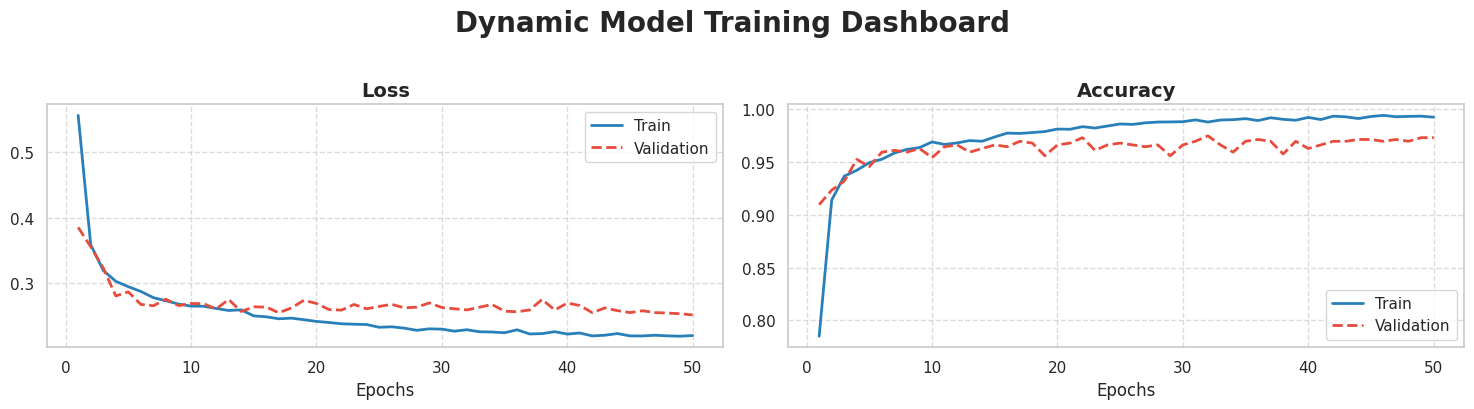

In [19]:
plot_dynamic_learning_curves(history)

# 🧪 Model Evaluation

2026-05-14 22:09:19.808620: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


📊 CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Normal       0.95      0.98      0.97       149
   Pneumonia       0.99      0.98      0.99       438

    accuracy                           0.98       587
   macro avg       0.97      0.98      0.98       587
weighted avg       0.98      0.98      0.98       587

-------------------------------------------------------
Accuracy           : 0.9830
Weighted Precision : 0.9832
Weighted Recall    : 0.9830
Weighted F1-Score  : 0.9830


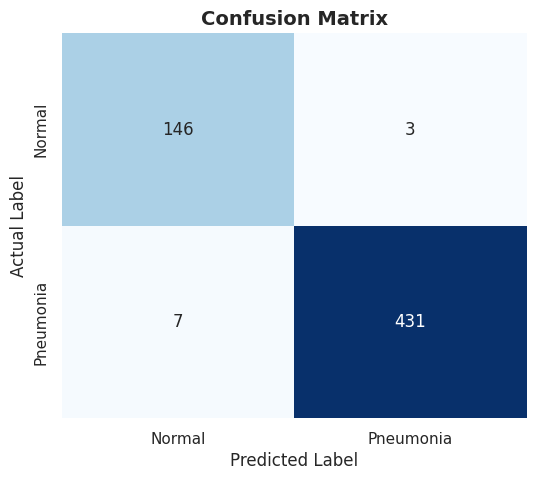

In [27]:
model.load_weights("pneumonia_cnn.h5")
y_proba = model.predict(x_test, verbose=0) 
y_pred = (y_proba >= 0.5).astype(int)
evaluate_classification(y_test, y_pred, class_names=["Normal", "Pneumonia"])

# 📊 ROC-AUC Curve

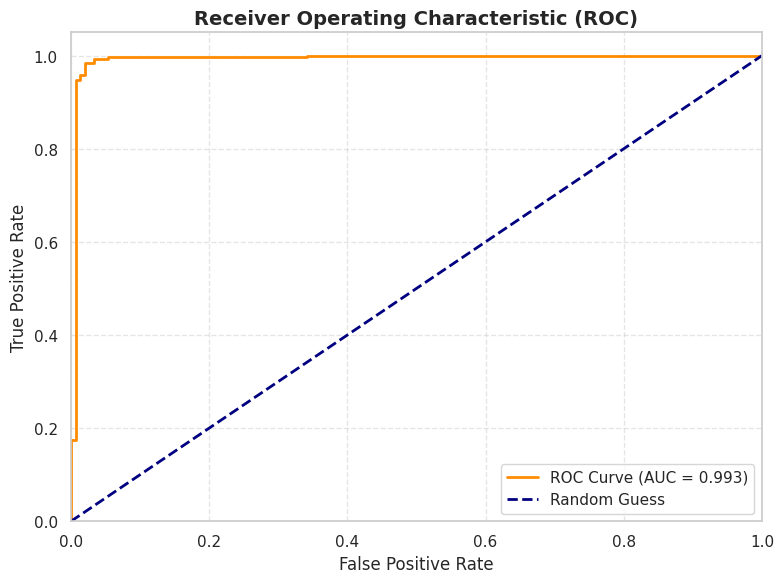

In [21]:
plot_roc_auc(y_test, y_proba, class_names=["Normal", "Pneumonia"])

# 🔎 Display Samples


=== Sample Predictions (with images) ===




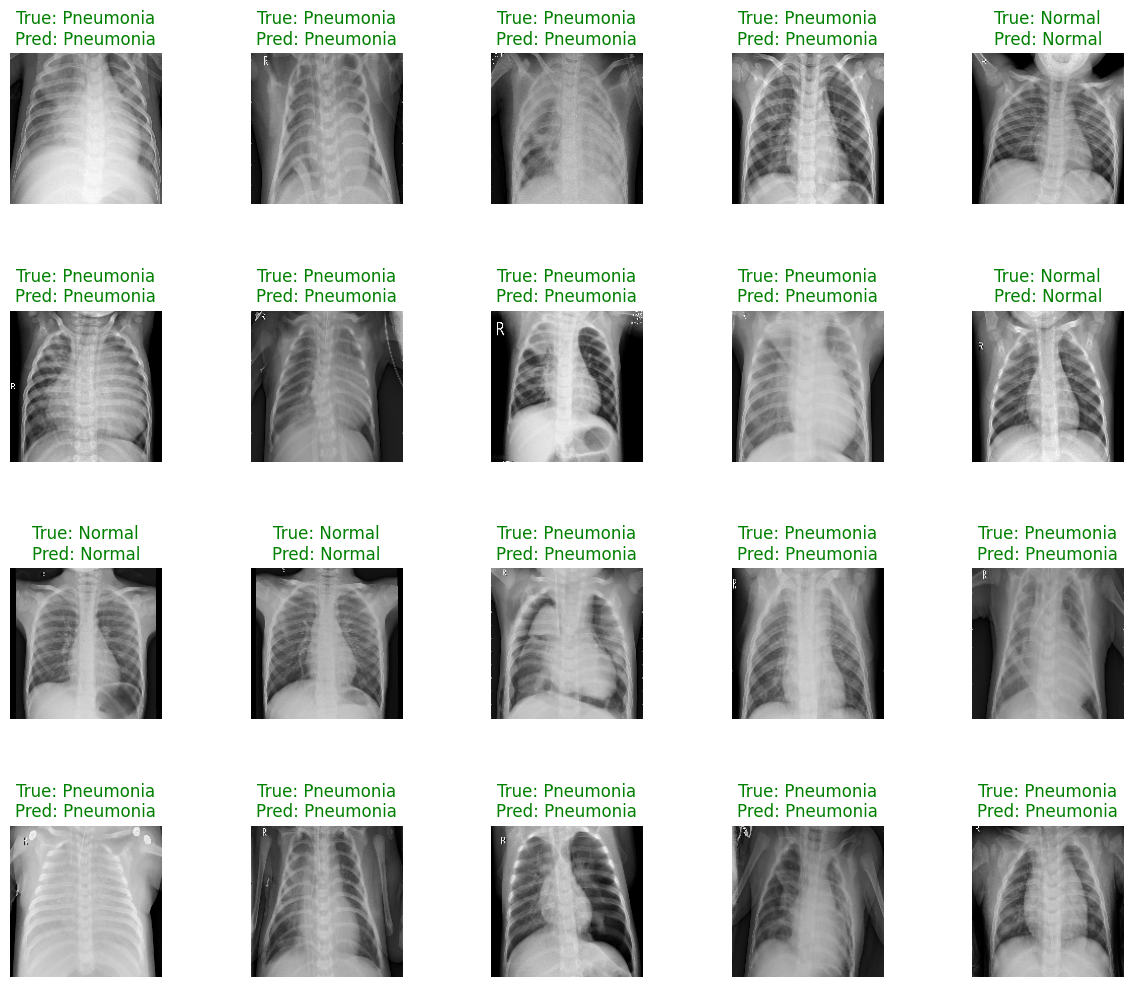

In [23]:
print("\n=== Sample Predictions (with images) ===\n\n") 
fig, axes = plt.subplots(4, 5, figsize=(15, 12)) 
fig.subplots_adjust(hspace=0.7)
class_names = ["Normal", "Pneumonia"]
for i, ax in enumerate(axes.flat): 
    true_label = class_names[int(y_test[i])] 
    pred_label = class_names[int(y_pred[i])] 
    img = x_test[i].squeeze() 
    color = "green" if true_label == pred_label else "red" 
    ax.imshow(img, cmap='gray') 
    ax.set_title(f"True: {true_label}\nPred: {pred_label}", fontsize=12,color=color) 
    ax.axis("off") 
plt.show() 

# 💾 Save Model

In [ ]:
export_for_deployment(model=model, preprocessor=None, model_name="pneumonia_cnn_model", preprocessor_name="pipeline", is_dl_model=False)